importamos todas las dependencias necesaria

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

utilizamos las funciones de numpy para inicializar la secuencia

In [37]:
np.random.seed(42)
n= 1000

inicializamos los datos ficticios

In [38]:
df = pd.DataFrame({
    'edad': np.random.randint(18, 70, n),
    'meses_cliente': np.random.randint(1, 60, n),
    'pagos_atrasados': np.random.randint(0, 6, n),
    'soporte_llamadas': np.random.randint(0, 10, n),
    'plan_premium': np.random.randint(0, 2, n),
    'gasto_mensual': np.random.randint(20, 200, n),
    })

ahora introducimos reglas a churn, las reglas son (si tiene mas de 3 pagos atrasados o mas de 6 llamas a soporte, se considera churn=1)

In [39]:
df['churn'] = (
    (df['pagos_atrasados'] > 3) |
    (df['soporte_llamadas'] > 6)
).astype(int)

df.head()

,edad,meses_cliente,pagos_atrasados,soporte_llamadas,plan_premium,gasto_mensual,churn
0,56,35,0,4,1,197,0
1,69,51,0,3,1,81,0
2,46,15,0,7,1,77,1
3,32,25,1,1,1,180,0
4,60,55,3,5,0,94,0


con la siguiente grafica, observamos como se separan las clases 0 y 1 conforme a los pagos atrasados

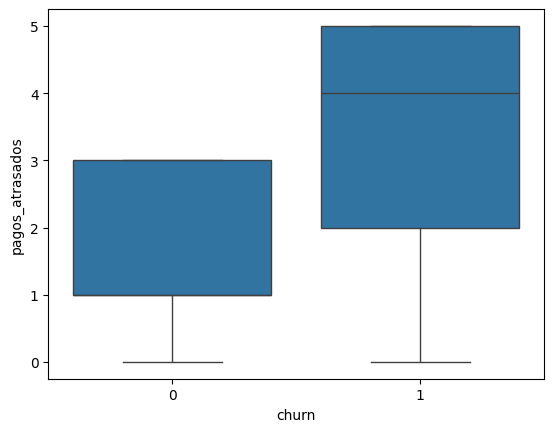

In [40]:
sns.boxplot(x = 'churn', y = 'pagos_atrasados', data=df)
plt.show()


entrenamos el modelo

In [41]:
X = df.drop('churn', axis= 1)
Y = df['churn']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

modelo= LogisticRegression(max_iter=1000)
modelo.fit(X_train, Y_train)



LogisticRegression(max_iter=1000)

mostramos los coeficientes de las columnas creadas, mientras mas cerca a 0 es menos probable que se vaya, mientas mas cerca o superior a 1 mas probable de que se vaya

In [42]:

coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo.coef_[0]
})

print(coeficientes)

           variable  coeficiente
0              edad    -0.005130
1     meses_cliente     0.003357
2   pagos_atrasados     1.530458
3  soporte_llamadas     0.853686
4      plan_premium     0.340767
5     gasto_mensual    -0.000552


aqui mostramos las metricas del modelo, en este caso tiene una precision de 0.87 para casos 0(se quedan) y 0.87 para casos que se van(1)

In [43]:
pred = modelo.predict(X_test)
print(classification_report(Y_test, pred))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85        94
           1       0.86      0.89      0.87       106

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200

